### ЗАВДАННЯ 5: РЕАЛІЗАЦІЯ БАГАТОШАРОВОГО ПЕРЦЕПТРОНУ З НУЛЯ В PYTORCH
Мета: дослідити та порівняти принципи роботи нейронних мереж через реалізацію власного механізму навчання та порівняння з фреймворком PyTorch для класифікації якості вина.

Датасет: WineQT.csv - оцінка якості вина.

#### Імпорт необхідних бібліотек

In [19]:
# комірка 1 - Імпорт бібліотек
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Фіксація випадковості для відтворюваності
np.random.seed(42)
torch.manual_seed(42)

# Кастомна конфігурація візуалізації
plt.style.use('default')
sns.set_style("whitegrid")
custom_palette = ["#FF6B6B", "#4ECDC4", "#45B7D1", "#96CEB4", "#FFEAA7", "#DDA0DD"]
sns.set_palette(custom_palette)

print("✅ Всі необхідні модулі успішно завантажено")
print(f"🔧 Версія PyTorch: {torch.__version__}")

✅ Всі необхідні модулі успішно завантажено
🔧 Версія PyTorch: 2.8.0


#### Завантаження та підготовка датасету Wine Quality для навчання

In [20]:
# Cell 2 - Data loading and preprocessing
def load_and_preprocess_data():
    """
    Завантажує та готує датасет Wine Quality для навчання
    
    Повертає:
        Кортеж з даними для тренування, валідації та тестування
    """
    print("📥 Завантаження даних з WineQT.csv...")

    # load data 
    wine_data = pd.read_csv('WineQT.csv')

    # remove unnecessary columns
    if 'Id' in wine_data.columns:
        wine_data = wine_data.drop('Id', axis=1)
    
    print(f"📊 Dataset shape: {wine_data.shape}")
    print("\n🔍 First 5 records:")
    print(wine_data.head())

    # separate features and labels
    features = wine_data.drop('quality', axis=1).values
    labels = wine_data['quality'].values

    # encode labels
    unique_classes = np.unique(labels)
    print(f"\n🎯 Quality classes: {unique_classes}")

    class_mapping = {quality: idx for idx, quality in enumerate(unique_classes)}
    encoded_labels = np.array([class_mapping[quality] for quality in labels])
    num_classes = len(unique_classes)
    
    print(f"📈 Number of classes: {num_classes}")
    print(f"📊 Class distribution: {np.bincount(encoded_labels)}")

    # stratified data splitting
    X_temp, X_test, y_temp, y_test = train_test_split(
        features, encoded_labels, test_size=0.2, random_state=42, stratify=encoded_labels
    )
    
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
    )

    print(f"\n📁 Розбиття датасету:")
    print(f"   Тренувальна вибірка: {X_train.shape[0]} зразків")
    print(f"   Валідаційна вибірка: {X_val.shape[0]} зразків")
    print(f"   Тестова вибірка: {X_test.shape[0]} зразків")
    
    # feature standardization
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    print("\n📐 Стандартизація даних завершена")

    # Convert to PyTorch tensors
    X_train = torch.FloatTensor(X_train)
    X_val = torch.FloatTensor(X_val)
    X_test = torch.FloatTensor(X_test)
    y_train = torch.LongTensor(y_train)
    y_val = torch.LongTensor(y_val)
    y_test = torch.LongTensor(y_test)
    
    print("\n✅ Підготовка даних завершена!")
    
    return X_train, X_val, X_test, y_train, y_val, y_test, num_classes, unique_classes

# Execute data preparation
X_train, X_val, X_test, y_train, y_val, y_test, num_classes, class_labels = load_and_preprocess_data()

📥 Завантаження даних з WineQT.csv...
📊 Dataset shape: (1143, 12)

🔍 First 5 records:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

 

#### Колекція функцій активації для нейронних мереж

In [21]:
# cell 3 - activation functions
class ActivationFunctions:
    """Колекція функцій активаціїї для нейронних мереж"""
    
    @staticmethod
    def relu(x, compute_grad=False):
        """Функція активації ReLU з підтримкою градієнта"""
        if compute_grad:
            return (x > 0).float()
        return torch.maximum(torch.zeros_like(x), x)
    
    @staticmethod
    def tanh(x, compute_grad=False):
        """Гіперболічний тангенс"""
        if compute_grad:
            return 1 - torch.tanh(x)**2
        return torch.tanh(x)
    
    @staticmethod
    def sigmoid(x, compute_grad=False):
        """Сигмоїдна функція активації"""
        sig_out = 1 / (1 + torch.exp(-x))
        if compute_grad:
            return sig_out * (1 - sig_out)
        return sig_out
    
    @staticmethod
    def softmax(x):
        """Числово стабільна реалізація softmax"""
        stable_exp = torch.exp(x - torch.max(x, dim=0, keepdim=True)[0])
        return stable_exp / torch.sum(stable_exp, dim=0, keepdim=True)

# Demo activation functions
print("\n🎭 Демонстрація функцій активації:")
demo_tensor = torch.tensor([[-2.0, -1.0, 0.0, 1.0, 2.0]])
print(f"Вхідний тензор: {demo_tensor}")
print(f"ReLU: {ActivationFunctions.relu(demo_tensor.T).T}")
print(f"Tanh: {ActivationFunctions.tanh(demo_tensor.T).T}")
print(f"Sigmoid: {ActivationFunctions.sigmoid(demo_tensor.T).T}")

print("\n📊 Приклад роботи softmax:")
softmax_input = torch.tensor([[1.0, 2.0, 3.0]])
softmax_output = ActivationFunctions.softmax(softmax_input.T).T
print(f"Вхід: {softmax_input}")
print(f"Softmax: {softmax_output}")
print(f"Сума: {torch.sum(softmax_output):.4f} (має бути 1.0000)")


🎭 Демонстрація функцій активації:
Вхідний тензор: tensor([[-2., -1.,  0.,  1.,  2.]])
ReLU: tensor([[0., 0., 0., 1., 2.]])
Tanh: tensor([[-0.9640, -0.7616,  0.0000,  0.7616,  0.9640]])
Sigmoid: tensor([[0.1192, 0.2689, 0.5000, 0.7311, 0.8808]])

📊 Приклад роботи softmax:
Вхід: tensor([[1., 2., 3.]])
Softmax: tensor([[0.0900, 0.2447, 0.6652]])
Сума: 1.0000 (має бути 1.0000)


#### Реалізація функцій втрат для навчання моделей. 
Клас містить власну реалізацію функцій втрат, необхідних для тренування нейронних мереж. Особливість - реалізація без використання autograd PyTorch, що дозволяє зрозуміти математичні основи оптимізації нейронних мереж.

In [22]:
# cell 4 - loss functions
class LossFunctions:
    """Реалізація функцій втрат для навчання моделей"""
    
    @staticmethod
    def cross_entropy(predictions, true_labels, compute_grad=False):
        """
        Функція крос-ентропії для задач класифікації
        
        Параметри: 
           predictions: передбачення (num_classes x batch_size)
           true_labels: справжні класи (batch_size)
           compute_grad: якщо True - повертає градієнт

        Повертає: 
           значення втрат або градієнт 
        """
        batch_size = true_labels.shape[0]
        
        if compute_grad:
            # Gradient for backpropagation
            grad = predictions.clone()
            for i in range(batch_size):
                grad[true_labels[i], i] -= 1
            return grad / batch_size
        else:
            # Calculate loss
            losses = []
            for i in range(batch_size):
                losses.append(-torch.log(predictions[true_labels[i], i] + 1e-8))
            total_loss = torch.sum(torch.stack(losses)) / batch_size
            return total_loss

print("✅ Функції втрат реалізовано!")

✅ Функції втрат реалізовано!


#### Власна реалізація нейронної мережі без використання autograd
Клас реалізує повноцінний багатошаровий перцептрон (MLP) з нуля, без використання автоматичного диференціювання PyTorch. Демонструє фундаментальні принципи роботи з нейронних мереж: ініціалізацію параметрів, прямий та зворотний прохід, оновлення ваг.

In [23]:
# cell 5 - custom neural network
class CustomNeuralNetwork:
    """
    Власна реалізація нейронної мережі без використання autograd
    """
    
    def __init__(self, architecture, activation_funcs, learning_rate=0.01):
        """
        Ініціалізація нейронної мережі
        
        Аргументи:
            architecture: Список розмірів шарів
            activation_funcs: Список назв функцій активації
            learning_rate: Швидкість навчання
        """
        self.architecture = architecture
        self.activation_funcs = activation_funcs
        self.learning_rate = learning_rate
        self.num_layers = len(architecture)
        self.params = {}
        
        print("🏗️  Побудова архітектури мережі...")
        
        # Initialize parameters
        for layer_idx in range(1, self.num_layers):
            # Initialize weights
            xavier_range = np.sqrt(6 / (architecture[layer_idx-1] + architecture[layer_idx]))
            self.params[f'W{layer_idx}'] = torch.FloatTensor(
                architecture[layer_idx], architecture[layer_idx-1]
            ).uniform_(-xavier_range, xavier_range)
            
            # Initialize biases
            self.params[f'b{layer_idx}'] = torch.zeros(architecture[layer_idx], 1)
            
            print(f"   Шар {layer_idx}: Ваги {self.params[f'W{layer_idx}'].shape}, "
                  f"Зміщення {self.params[f'b{layer_idx}'].shape}")
        
        print(f"\n✅ Мережа створена: {architecture}")
        print(f"   Функції активації: {activation_funcs}")
    
    def forward_pass(self, input_data, training_mode=True):
        """Виконує прямий прохід через мережу"""
        cache = {}
        current_activation = input_data.T
        cache['A0'] = current_activation
        
        for layer_idx in range(1, self.num_layers):
            # Linear transformation
            linear_out = self.params[f'W{layer_idx}'] @ current_activation + self.params[f'b{layer_idx}']
            
            # Apply activation
            if layer_idx == self.num_layers - 1:
                # Output layer
                current_activation = ActivationFunctions.softmax(linear_out)
            else:
                # Hidden layers
                activation_func = getattr(ActivationFunctions, self.activation_funcs[layer_idx-1])
                current_activation = activation_func(linear_out)
            
            # Store for backpropagation
            if training_mode:
                cache[f'Z{layer_idx}'] = linear_out
                cache[f'A{layer_idx}'] = current_activation
        
        if training_mode:
            return current_activation, cache
        else:
            return current_activation
    
    def backward_pass(self, input_data, true_labels, cache):
        """Виконує зворотне поширення помилки для обчислення градієнтів"""
        batch_size = input_data.shape[0]
        grads = {}
        
        # Output layer gradient
        dZ = LossFunctions.cross_entropy(cache[f'A{self.num_layers-1}'], true_labels, compute_grad=True)
        
        # Backpropagate through layers
        for layer_idx in range(self.num_layers - 1, 0, -1):
            prev_activation = cache[f'A{layer_idx-1}']
            
            # Gradients for weights and biases
            grads[f'dW{layer_idx}'] = dZ @ prev_activation.T
            grads[f'db{layer_idx}'] = torch.sum(dZ, dim=1, keepdim=True)
            
            # Propagate gradient to previous layer
            if layer_idx > 1:
                dA = self.params[f'W{layer_idx}'].T @ dZ
                activation_func = getattr(ActivationFunctions, self.activation_funcs[layer_idx-2])
                dZ = dA * activation_func(cache[f'Z{layer_idx-1}'], compute_grad=True)
        
        # Update parameters
        for layer_idx in range(1, self.num_layers):
            self.params[f'W{layer_idx}'] -= self.learning_rate * grads[f'dW{layer_idx}']
            self.params[f'b{layer_idx}'] -= self.learning_rate * grads[f'db{layer_idx}']
    
    def train_step(self, input_data, true_labels):
        """Виконує одну ітерацію навчання"""
        # Forward pass
        predictions, cache = self.forward_pass(input_data, training_mode=True)
        
        # Calculate loss
        loss = LossFunctions.cross_entropy(predictions, true_labels)
        
        # Backward pass
        self.backward_pass(input_data, true_labels, cache)
        
        # Calculate accuracy
        predicted_classes = torch.argmax(predictions, dim=0)
        accuracy = (predicted_classes == true_labels).float().mean()
        
        return loss.item(), accuracy.item()
    
    def predict(self, input_data):
        """Робить передбачення на вхідних даних"""
        predictions = self.forward_pass(input_data, training_mode=False)
        return torch.argmax(predictions, dim=0)
    
    def evaluate(self, input_data, true_labels):
        """Оцінює продуктивність моделі"""
        predictions = self.forward_pass(input_data, training_mode=False)
        loss = LossFunctions.cross_entropy(predictions, true_labels)
        predicted_classes = torch.argmax(predictions, dim=0)
        accuracy = (predicted_classes == true_labels).float().mean()
        return loss.item(), accuracy.item()

print("✅ Клас власної нейронної мережі створено")

✅ Клас власної нейронної мережі створено


#### Навчання власної реалізації нейронної мережі
Функція виконує повний цикл навчання власної моделі без використання автоматичного диференціювання PyTorch. Демонструє фундаментальний процес тренування нейронних мереж: ітерації по епохах, оцінка на валідації, моніторинг прогресу та збереження історії навчання.
Повертає: словник з історією навчання (втрати та точність для кожної епохи)

In [24]:
# cell 6 - custom model training 
def train_custom_model(model, X_train, y_train, X_val, y_val, num_epochs=1000, log_freq=100):
    """
    Навчання власної реалізації нейронної мережі
    
    Повертає:
        Словник з історією навчання
    """
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    print(f"\n{'='*60}")
    print("НАВЧАННЯ ВЛАСНОЇ МОДЕЛІ")
    print(f"{'='*60}\n")
    
    for epoch in range(num_epochs):
        # Training step
        train_loss, train_acc = model.train_step(X_train, y_train)
        
        # Validation step
        val_loss, val_acc = model.evaluate(X_val, y_val)
        
        # Log metrics
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Progress logging
        if (epoch + 1) % log_freq == 0 or epoch == 0:
            print(f"Епоха {epoch+1:4d}/{num_epochs} | "
                  f"Тренувальні втрати: {train_loss:.4f} | Тренувальна точність: {train_acc:.4f} | "
                  f"Валідаційні втрати: {val_loss:.4f} | Валідаційна точність: {val_acc:.4f}")
    
    print(f"\n{'='*60}")
    print("✅ Навчання власної моделі завершено")
    print(f"{'='*60}\n")
    
    return history

print("✅ Функція навчання власної моделі готова")

✅ Функція навчання власної моделі готова


#### Нейронна мережа на PyTorch для порівняння
Клас реалізує еквівалентну нейронну мережу з використанням вбудованих компонентів PyTorch. Слугує еталоном для порівняння з власною реалізацією, демонструючи, як сучасні бібліотеки спрощують створення та навчання моделей.

In [25]:
# cell 7 - PyTorch model
class PyTorchNeuralNetwork(nn.Module):
    """
    Нейронна мережа на PyTorch для порівняння
    """
    
    def __init__(self, input_dim, hidden_dims, output_dim, activations):
        """
        Аргументи:
            input_dim: Розмірність вхідного шару
            hidden_dims: Список розмірів прихованих шарів
            output_dim: Розмірність вихідного шару
            activations: Список функцій активації
        """
        super(PyTorchNeuralNetwork, self).__init__()
        
        # Build network layers
        layers = []
        current_dim = input_dim
        
        # Add hidden layers
        for idx, hidden_dim in enumerate(hidden_dims):
            layers.append(nn.Linear(current_dim, hidden_dim))
            
            # Add activation function
            if activations[idx] == 'relu':
                layers.append(nn.ReLU())
            elif activations[idx] == 'tanh':
                layers.append(nn.Tanh())
            elif activations[idx] == 'sigmoid':
                layers.append(nn.Sigmoid())
            
            current_dim = hidden_dim
        
        # Add output layer
        layers.append(nn.Linear(current_dim, output_dim))
        
        # Create sequential model
        self.network = nn.Sequential(*layers)
        
        print(f"✅ PyTorch нейронна мережа створена:")
        print(f"   Архітектура: {[input_dim] + hidden_dims + [output_dim]}")
        print(f"   Функції активації: {activations}")
    
    def forward(self, x):
        """Прямий прохід"""
        return self.network(x)

print("✅ Клас PyTorch нейронної мережі створено")

✅ Клас PyTorch нейронної мережі створено


#### Навчання PyTorch моделі з використанням вбудованих інструментів фреймворку.
Демонструє стандартний підхід до навчання нейронних мереж в PyTorch з використанням автоматичного диференціювання (autograd), оптимізаторів та вбудованих функцій втрат. Слугує еталоном для порівняння з власною реалізацією.
Повертає: словник з історією навчання (втрати та точність для кожної епохи)

In [26]:
# cell 8 - PyTorch model training
def train_pytorch_model(model, X_train, y_train, X_val, y_val, num_epochs=1000, 
                        learning_rate=0.01, log_freq=100):
    """
    Навчання PyTorch моделі
    
    Повертає:
        Словник з історією навчання
    """
    # Loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    print(f"\n{'='*60}")
    print("НАВЧАННЯ PYTORCH МОДЕЛІ")
    print(f"{'='*60}\n")
    
    for epoch in range(num_epochs):
        # Training mode
        model.train()
        
        # Forward pass
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Calculate training accuracy
        _, predicted = torch.max(outputs.data, 1)
        train_acc = (predicted == y_train).float().mean().item()
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)
            _, val_predicted = torch.max(val_outputs.data, 1)
            val_acc = (val_predicted == y_val).float().mean().item()
        
        # Store metrics
        history['train_loss'].append(loss.item())
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss.item())
        history['val_acc'].append(val_acc)
        
        # Progress logging
        if (epoch + 1) % log_freq == 0 or epoch == 0:
            print(f"Епоха {epoch+1:4d}/{num_epochs} | "
                  f"Тренувальні втрати: {loss.item():.4f} | Тренувальна точність: {train_acc:.4f} | "
                  f"Валідаційні втрати: {val_loss.item():.4f} | Валідаційна точність: {val_acc:.4f}")
    
    print(f"\n{'='*60}")
    print("✅ Навчання PyTorch моделі завершено")
    print(f"{'='*60}\n")
    
    return history

print("✅ Функція навчання PyTorch моделі готова")


✅ Функція навчання PyTorch моделі готова


#### Візуалізація прогресу навчання обох моделей
Функція створює комплексну візуалізацію процесу навчання двох моделей: 
1. Власної реалізації (без autograd)
2. PyTorch реалізації (з autograd)

Візуалізація довзоляє порівняти: 
- швидкість збіжності моделей
- ознаки перенавчання (розрив train/val)
- стабільність навчання 
- фінальну якість на валідації

Ключові аналітичні моменти: 
- синхронне зниження train/val loss - гарна узагальнююча здатність
- розбіжність train/val accuracy > 5-10% - можливе перенавчання 
- різка мінливість кривих - можливо завелика швидкість навчання

In [27]:
# cell 9 - training visualization
def visualize_training(custom_history, pytorch_history):
    """
    Візуалізація прогресу навчання обох моделей
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    custom_epochs = range(1, len(custom_history['train_loss']) + 1)
    pytorch_epochs = range(1, len(pytorch_history['train_loss']) + 1)
    
    # Custom model - Loss
    axes[0, 0].plot(custom_epochs, custom_history['train_loss'], 
                   label='Тренувальні втрати', linewidth=2.5, alpha=0.9, color='#E63946')
    axes[0, 0].plot(custom_epochs, custom_history['val_loss'], 
                   label='Валідаційні втрати', linewidth=2.5, alpha=0.9, color='#457B9D')
    axes[0, 0].set_title('Власна модель - Еволюція втрат', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Епоха')
    axes[0, 0].set_ylabel('Втрати')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3, linestyle='--')
    
    # Custom model - Accuracy
    axes[0, 1].plot(custom_epochs, custom_history['train_acc'], 
                   label='Тренувальна точність', linewidth=2.5, alpha=0.9, color='#2A9D8F')
    axes[0, 1].plot(custom_epochs, custom_history['val_acc'], 
                   label='Валідаційна точність', linewidth=2.5, alpha=0.9, color='#E9C46A')
    axes[0, 1].set_title('Власна модель - Еволюція точності', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Епоха')
    axes[0, 1].set_ylabel('Точність')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3, linestyle='--')
    
    # PyTorch model - Loss
    axes[1, 0].plot(pytorch_epochs, pytorch_history['train_loss'], 
                   label='Тренувальні втрати', linewidth=2.5, alpha=0.9, color='#9B5DE5')
    axes[1, 0].plot(pytorch_epochs, pytorch_history['val_loss'], 
                   label='Валідаційні втрати', linewidth=2.5, alpha=0.9, color='#00BBF9')
    axes[1, 0].set_title('PyTorch модель - Еволюція втрат', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Епоха')
    axes[1, 0].set_ylabel('Втрати')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3, linestyle='--')
    
    # PyTorch model - Accuracy
    axes[1, 1].plot(pytorch_epochs, pytorch_history['train_acc'], 
                   label='Тренувальна точність', linewidth=2.5, alpha=0.9, color='#F15BB5')
    axes[1, 1].plot(pytorch_epochs, pytorch_history['val_acc'], 
                   label='Валідаційна точність', linewidth=2.5, alpha=0.9, color='#00F5D4')
    axes[1, 1].set_title('PyTorch модель - Еволюція точності', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Епоха')
    axes[1, 1].set_ylabel('Точність')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    # Comparative analysis
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Validation loss comparison
    axes[0].plot(custom_epochs, custom_history['val_loss'], 
                label='Власна модель', linewidth=3, alpha=0.8, color='#264653')
    axes[0].plot(pytorch_epochs, pytorch_history['val_loss'], 
                label='PyTorch модель', linewidth=3, alpha=0.8, color='#E76F51')
    axes[0].set_title('Порівняння валідаційних втрат', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Епоха')
    axes[0].set_ylabel('Валідаційні втрати')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, linestyle='--')
    
    # Validation accuracy comparison
    axes[1].plot(custom_epochs, custom_history['val_acc'], 
                label='Власна модель', linewidth=3, alpha=0.8, color='#2A9D8F')
    axes[1].plot(pytorch_epochs, pytorch_history['val_acc'], 
                label='PyTorch модель', linewidth=3, alpha=0.8, color='#F4A261')
    axes[1].set_title('Порівняння валідаційної точності', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Епоха')
    axes[1].set_ylabel('Валідаційна точність')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()

print("✅ Функція візуалізації навчання готова")

✅ Функція візуалізації навчання готова


#### Візуалізація матриць неточностей для обох моделей
Матриці неточностей (Confusion Matrix) - ключовий інструмент для оцінки якості класифікаційних моделей. Вони показують, як модель плутає різні класи.

Classification Report містить детальні метрики: 
- Precision (точність): скільки з прогнозованих класів правильні 
- Recall (повнота): скільки з реальних класів знайдені 
- F1-Score: гармонійне середнє precision та recall
- Support: кількість зразків кожного класу

In [28]:
# cell 10 - cunfusion matrix visualization
def visualize_confusion_matrices(true_labels, custom_preds, pytorch_preds, class_labels):
    """
    Візуалізація матриць неточностей для обох моделей
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Custom model confusion matrix
    custom_cm = confusion_matrix(true_labels, custom_preds)
    sns.heatmap(custom_cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels,
                ax=axes[0], cbar_kws={'label': 'Кількість'}, linewidths=0.5)
    axes[0].set_title('Власна модель - Матриця неточностей', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Передбачений клас', fontsize=12)
    axes[0].set_ylabel('Справжній клас', fontsize=12)
    
    # PyTorch model confusion matrix
    pytorch_cm = confusion_matrix(true_labels, pytorch_preds)
    sns.heatmap(pytorch_cm, annot=True, fmt='d', cmap='Oranges', 
                xticklabels=class_labels, yticklabels=class_labels,
                ax=axes[1], cbar_kws={'label': 'Кількість'}, linewidths=0.5)
    axes[1].set_title('PyTorch модель - Матриця неточностей', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Передбачений клас', fontsize=12)
    axes[1].set_ylabel('Справжній клас', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Classification reports
    print("\n" + "="*70)
    print("ЗВІТ КЛАСИФІКАЦІЇ - ВЛАСНА МОДЕЛЬ")
    print("="*70)
    print(classification_report(true_labels, custom_preds, 
                               target_names=[f"Клас {c}" for c in class_labels]))
    
    print("\n" + "="*70)
    print("ЗВІТ КЛАСИФІКАЦІЇ - PYTORCH МОДЕЛЬ")
    print("="*70)
    print(classification_report(true_labels, pytorch_preds, 
                               target_names=[f"Клас {c}" for c in class_labels]))

print("✅ Функція візуалізації матриць неточностей готова")

✅ Функція візуалізації матриць неточностей готова


#### Визначення гіперпараметрів моделі для обох реалізацій
Гіперпараметри - це параметри, які задаються перед початком навчання і не змінюються під час нього. Правильний вибір гіперпараметрів критично важливий для успішного навчання нейронної мережі.
Для чесного порівняння обох моделей використовуємо ідентичні гіперпараметри.

In [29]:
# cell 11 - model hyperparameters
input_dim = X_train.shape[1]
hidden_arch = [64, 32]
output_dim = num_classes
activations = ['relu', 'relu']
learning_rate = 0.01
epochs = 1000

print(f"📐 Архітектура мережі: {[input_dim] + hidden_arch + [output_dim]}")
print(f"⚡ Функції активації: {activations}")
print(f"📊 Швидкість навчання: {learning_rate}")
print(f"🔄 Кількість епох: {epochs}")
print(f"🎯 Кількість класів: {output_dim}")

📐 Архітектура мережі: [11, 64, 32, 6]
⚡ Функції активації: ['relu', 'relu']
📊 Швидкість навчання: 0.01
🔄 Кількість епох: 1000
🎯 Кількість класів: 6


#### Тренування власної реалізації нейронної мережі 
На цьому етапі навчаємо модель, яку створили з нуля без використання автоматичного диференціювання PyTorch. Це демонструє повний цикл навчання нейронної мережі на рівні математичних операцій.

In [30]:
# cell 12 - train custom model
network_arch = [input_dim] + hidden_arch + [output_dim]
custom_model = CustomNeuralNetwork(network_arch, activations, learning_rate)

import time
start_time = time.time()
custom_history = train_custom_model(custom_model, X_train, y_train, X_val, y_val, 
                                   num_epochs=epochs, log_freq=100)
custom_training_time = time.time() - start_time

print(f"⏱️  Час навчання власної моделі: {custom_training_time:.2f} секунд")

🏗️  Побудова архітектури мережі...
   Шар 1: Ваги torch.Size([64, 11]), Зміщення torch.Size([64, 1])
   Шар 2: Ваги torch.Size([32, 64]), Зміщення torch.Size([32, 1])
   Шар 3: Ваги torch.Size([6, 32]), Зміщення torch.Size([6, 1])

✅ Мережа створена: [11, 64, 32, 6]
   Функції активації: ['relu', 'relu']

НАВЧАННЯ ВЛАСНОЇ МОДЕЛІ

Епоха    1/1000 | Тренувальні втрати: 1.8413 | Тренувальна точність: 0.1477 | Валідаційні втрати: 1.8142 | Валідаційна точність: 0.1475
Епоха  100/1000 | Тренувальні втрати: 1.2889 | Тренувальна точність: 0.5157 | Валідаційні втрати: 1.2575 | Валідаційна точність: 0.5683
Епоха  200/1000 | Тренувальні втрати: 1.1406 | Тренувальна точність: 0.5472 | Валідаційні втрати: 1.1094 | Валідаційна точність: 0.5683
Епоха  300/1000 | Тренувальні втрати: 1.0737 | Тренувальна точність: 0.5636 | Валідаційні втрати: 1.0450 | Валідаційна точність: 0.5847
Епоха  400/1000 | Тренувальні втрати: 1.0350 | Тренувальна точність: 0.5691 | Валідаційні втрати: 1.0108 | Валідаційна точні

#### Тренування PyTorch реалізації нейронної мережі 
На цьому етапі навчаємо еквівалентну модель, створену за допомогою вбудованих компонентів PyTorch. Це демонструє, як сучасні ML-фреймворки спрощують та прискорюють процес навчання нейронних мереж.


In [31]:
# cell 13 - train PyTorch model
pytorch_model = PyTorchNeuralNetwork(input_dim, hidden_arch, output_dim, ['relu', 'relu'])

start_time = time.time()
pytorch_history = train_pytorch_model(pytorch_model, X_train, y_train, X_val, y_val,
                                     num_epochs=epochs, learning_rate=learning_rate, 
                                     log_freq=100)
pytorch_training_time = time.time() - start_time

print(f"⏱️  Час навчання PyTorch моделі: {pytorch_training_time:.2f} секунд")


✅ PyTorch нейронна мережа створена:
   Архітектура: [11, 64, 32, 6]
   Функції активації: ['relu', 'relu']

НАВЧАННЯ PYTORCH МОДЕЛІ

Епоха    1/1000 | Тренувальні втрати: 1.8568 | Тренувальна точність: 0.0985 | Валідаційні втрати: 1.6768 | Валідаційна точність: 0.4262
Епоха  100/1000 | Тренувальні втрати: 0.4072 | Тренувальна точність: 0.8687 | Валідаційні втрати: 1.3209 | Валідаційна точність: 0.5519
Епоха  200/1000 | Тренувальні втрати: 0.0677 | Тренувальна точність: 0.9986 | Валідаційні втрати: 2.5139 | Валідаційна точність: 0.5902
Епоха  300/1000 | Тренувальні втрати: 0.0149 | Тренувальна точність: 1.0000 | Валідаційні втрати: 3.6079 | Валідаційна точність: 0.5683
Епоха  400/1000 | Тренувальні втрати: 0.0062 | Тренувальна точність: 1.0000 | Валідаційні втрати: 4.2469 | Валідаційна точність: 0.5738
Епоха  500/1000 | Тренувальні втрати: 0.0034 | Тренувальна точність: 1.0000 | Валідаційні втрати: 4.6645 | Валідаційна точність: 0.5738
Епоха  600/1000 | Тренувальні втрати: 0.0022 | Трен

Візуалізація прогресу навчання обох моделей

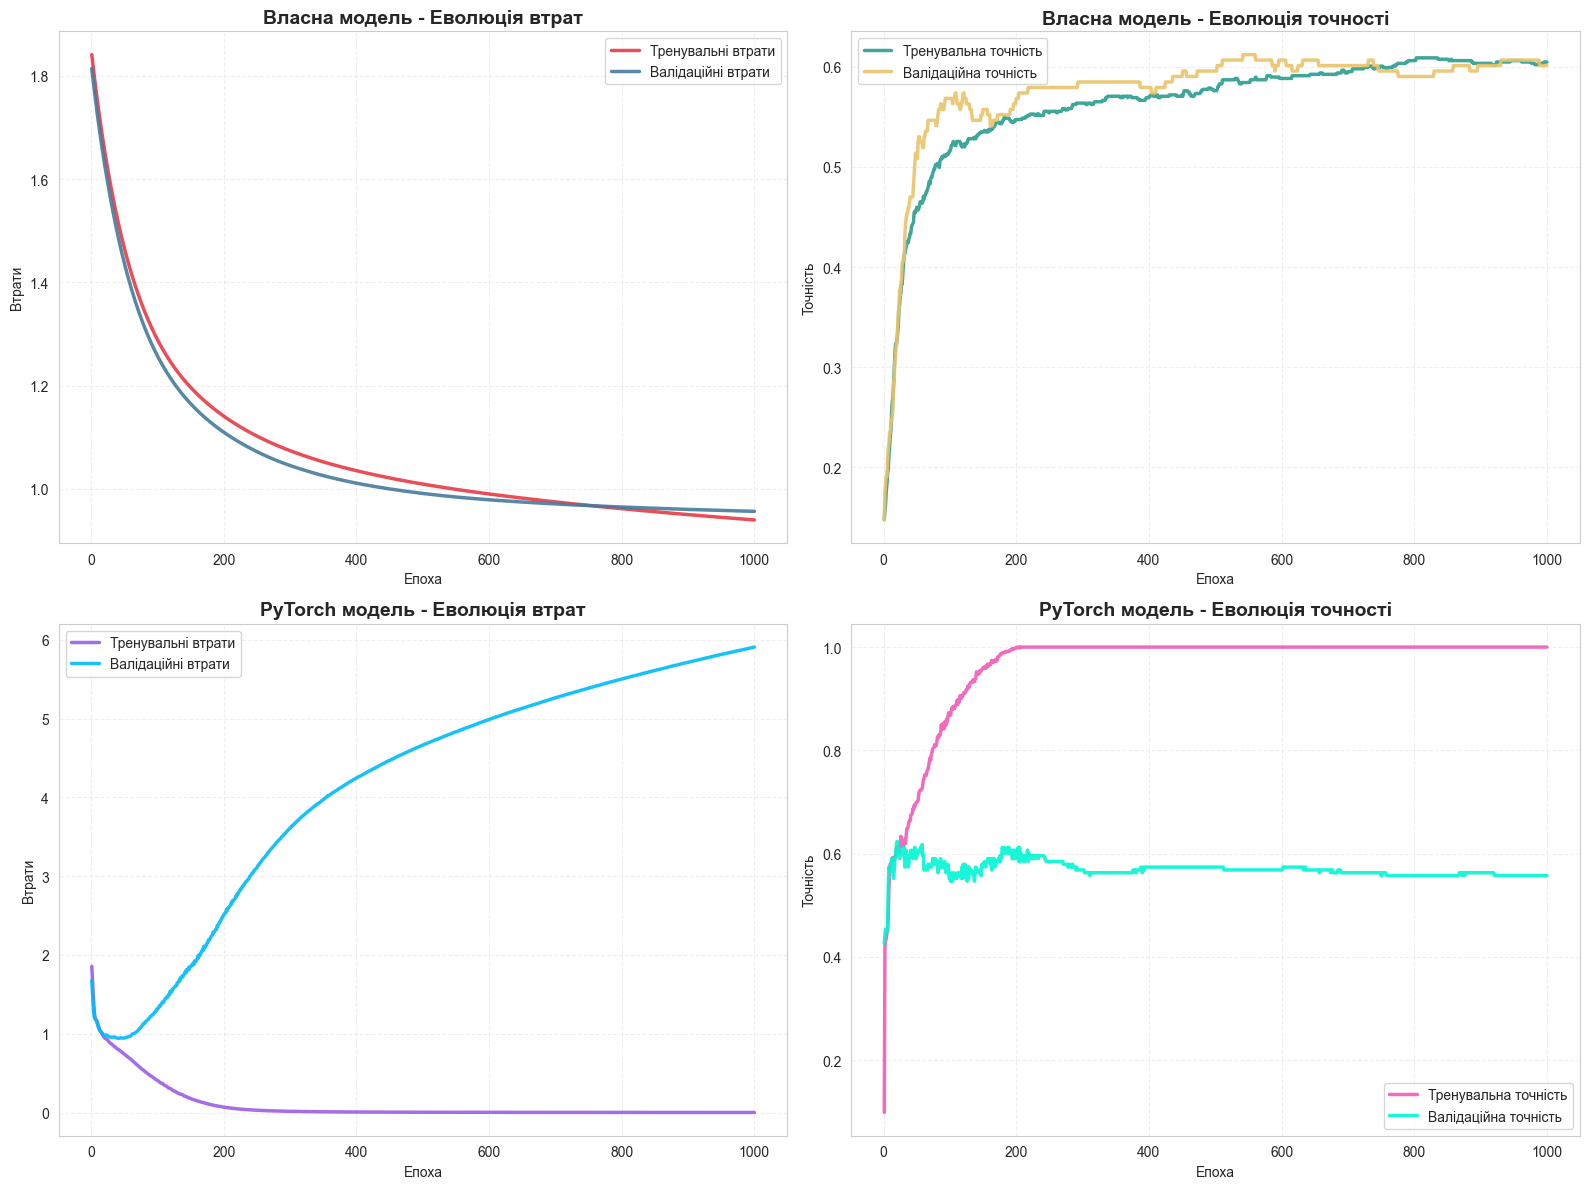

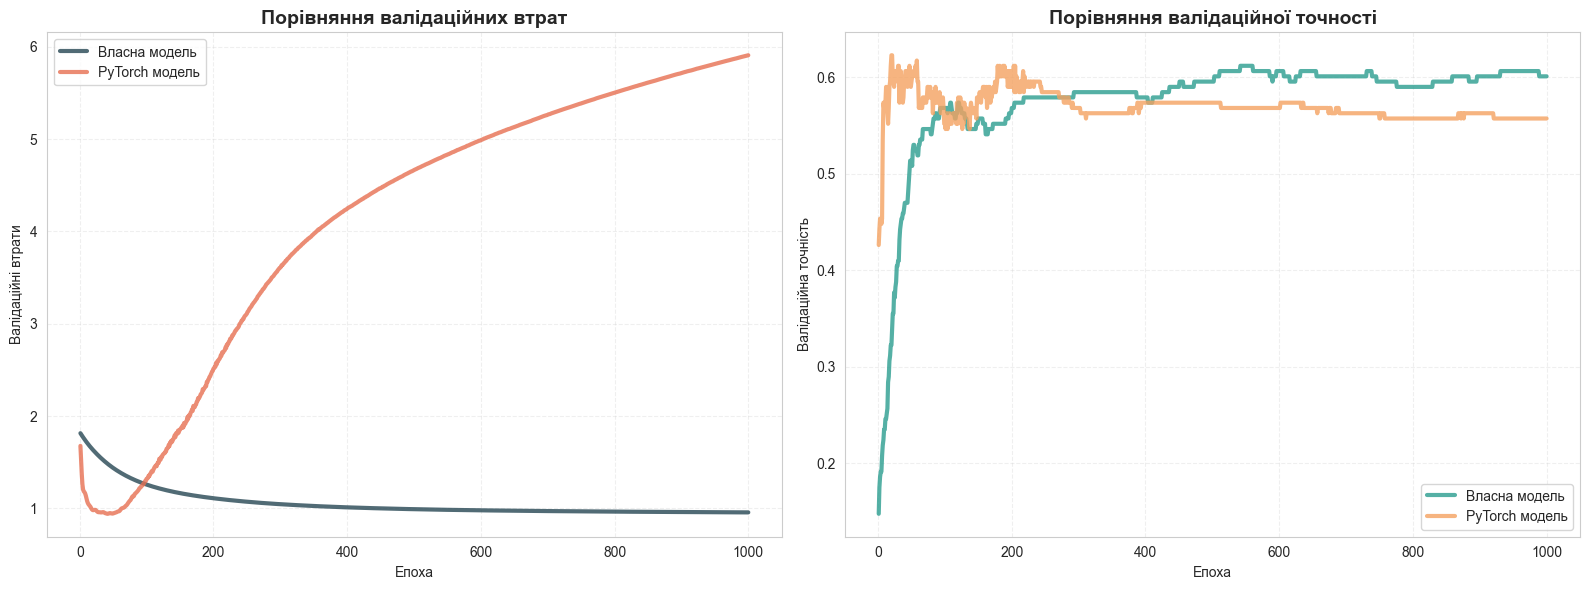

In [32]:
# cell 14 - visualize training progress
visualize_training(custom_history, pytorch_history)

#### Аналіз явища перенавчання для обох моделей
Перенавчання (overfitting) - це ключова проблема в машинному навчанні, коли модель надто добре навчається на тренувальних даних, але погано узагальнює на нових даних.

Критерії оцінки: 
- різниця між тренувальними та валідаційними метриками
- динаміка зміни втрат під час навчання 
- стабільність досягнутих результатів

Цей аналіз допомагає: 
- оцінити здатність моделей до узагальнення 
- виявити проблеми з архітектурою чи гіперпараметрами
- порівняти стабільність двох реалізацій
- дати рекомендації щодо покращення моделей

In [33]:
# cell 15 - overfitting analysis
def analyze_overfitting(custom_history, pytorch_history):
    """
    Детальний аналіз явища перенавчання для обох моделей
    """
    print("="*70)
    print("АНАЛІЗ ПЕРЕНАВЧАННЯ")
    print("="*70)
    
    # Custom model analysis
    print("\n🔍 ВЛАСНА МОДЕЛЬ:")
    print("-" * 70)
    
    final_train_loss_custom = custom_history['train_loss'][-1]
    final_val_loss_custom = custom_history['val_loss'][-1]
    final_train_acc_custom = custom_history['train_acc'][-1]
    final_val_acc_custom = custom_history['val_acc'][-1]
    
    loss_gap_custom = final_train_loss_custom - final_val_loss_custom
    acc_gap_custom = final_train_acc_custom - final_val_acc_custom
    
    print(f"  Фінальні тренувальні втрати:    {final_train_loss_custom:.4f}")
    print(f"  Фінальні валідаційні втрати:   {final_val_loss_custom:.4f}")
    print(f"  Різниця втрат (Трен - Вал):  {loss_gap_custom:.4f}")
    print()
    print(f"  Фінальна тренувальна точність:    {final_train_acc_custom:.4f} ({final_train_acc_custom*100:.2f}%)")
    print(f"  Фінальна валідаційна точність:  {final_val_acc_custom:.4f} ({final_val_acc_custom*100:.2f}%)")
    print(f"  Різниця точності (Трен - Вал): {acc_gap_custom:.4f} ({acc_gap_custom*100:.2f}%)")
    
    # PyTorch model analysis
    print("\n🔍 PYTORCH МОДЕЛЬ:")
    print("-" * 70)
    
    final_train_loss_torch = pytorch_history['train_loss'][-1]
    final_val_loss_torch = pytorch_history['val_loss'][-1]
    final_train_acc_torch = pytorch_history['train_acc'][-1]
    final_val_acc_torch = pytorch_history['val_acc'][-1]
    
    loss_gap_torch = final_train_loss_torch - final_val_loss_torch
    acc_gap_torch = final_train_acc_torch - final_val_acc_torch
    
    print(f"  Фінальні тренувальні втрати:    {final_train_loss_torch:.4f}")
    print(f"  Фінальні валідаційні втрати:   {final_val_loss_torch:.4f}")
    print(f"  Різниця втрат (Трен - Вал):  {loss_gap_torch:.4f}")
    print()
    print(f"  Фінальна тренувальна точність:    {final_train_acc_torch:.4f} ({final_train_acc_torch*100:.2f}%)")
    print(f"  Фінальна валідаційна точність:  {final_val_acc_torch:.4f} ({final_val_acc_torch*100:.2f}%)")
    print(f"  Різниця точності (Трен - Вал): {acc_gap_torch:.4f} ({acc_gap_torch*100:.2f}%)")
    
    # Interpretation
    print("\n" + "="*70)
    print("📊 ІНТЕРПРЕТАЦІЯ:")
    print("="*70)
    
    # Overfitting thresholds
    loss_threshold = 0.1
    acc_threshold = 0.05
    
    print("\n1️⃣ ВЛАСНА МОДЕЛЬ:")
    if loss_gap_custom > loss_threshold or acc_gap_custom > acc_threshold:
        print("   ⚠️  ВИЯВЛЕНО ОЗНАКИ ПЕРЕНАВЧАННЯ")
        if loss_gap_custom > loss_threshold:
            print(f"      - Тренувальні втрати значно нижчі за валідаційні (різниця: {loss_gap_custom:.4f})")
        if acc_gap_custom > acc_threshold:
            print(f"      - Тренувальна точність значно вища за валідаційну (різниця: {acc_gap_custom*100:.2f}%)")
    else:
        print("   ✅ ПЕРЕНАВЧАННЯ ВІДСУТНЄ")
        print("      - Модель демонструє гарну узагальнюючу здатність")
    
    print("\n2️⃣ PYTORCH МОДЕЛЬ:")
    if loss_gap_torch > loss_threshold or acc_gap_torch > acc_threshold:
        print("   ⚠️  ВИЯВЛЕНО ОЗНАКИ ПЕРЕНАВЧАННЯ")
        if loss_gap_torch > loss_threshold:
            print(f"      - Тренувальні втрати значно нижчі за валідаційні (різниця: {loss_gap_torch:.4f})")
        if acc_gap_torch > acc_threshold:
            print(f"      - Тренувальна точність значно вища за валідаційну (різниця: {acc_gap_torch*100:.2f}%)")
    else:
        print("   ✅ ПЕРЕНАВЧАННЯ ВІДСУТНЄ")
        print("      - Модель демонструє гарну узагальнюючу здатність")
    
    print("\n" + "="*70)
    print("🎯 ПРАКТИЧНІ РЕКОМЕНДАЦІЇ:")
    print("="*70)
    print("""
    ✓ ОЗНАКИ ПЕРЕНАВЧАННЯ:
      1. Тренувальні втрати продовжують знижуватись, а валідаційні зростають
      2. Значна різниця між тренувальною та валідаційною точністю (>5-10%)
      3. Ідеальні результати на тренувальних даних
      4. Валідаційні втрати починають зростати після певної епохи
    
    ✓ ОЗНАКИ ГАРНОЇ УЗАГАЛЬНЮВАЛЬНОЇ ЗДАТНОСТІ:
      1. Тренувальні та валідаційні втрати знижуються синхронно
      2. Мінімальна різниця між тренувальними та валідаційними метриками
      3. Валідаційні показники стабілізуються на високому рівні
      4. Обидві криві демонструють збіжність до схожих значень
    """)
    
    print("="*70)

# Run overfitting analysis
analyze_overfitting(custom_history, pytorch_history)


АНАЛІЗ ПЕРЕНАВЧАННЯ

🔍 ВЛАСНА МОДЕЛЬ:
----------------------------------------------------------------------
  Фінальні тренувальні втрати:    0.9395
  Фінальні валідаційні втрати:   0.9562
  Різниця втрат (Трен - Вал):  -0.0167

  Фінальна тренувальна точність:    0.6047 (60.47%)
  Фінальна валідаційна точність:  0.6011 (60.11%)
  Різниця точності (Трен - Вал): 0.0036 (0.36%)

🔍 PYTORCH МОДЕЛЬ:
----------------------------------------------------------------------
  Фінальні тренувальні втрати:    0.0007
  Фінальні валідаційні втрати:   5.9089
  Різниця втрат (Трен - Вал):  -5.9082

  Фінальна тренувальна точність:    1.0000 (100.00%)
  Фінальна валідаційна точність:  0.5574 (55.74%)
  Різниця точності (Трен - Вал): 0.4426 (44.26%)

📊 ІНТЕРПРЕТАЦІЯ:

1️⃣ ВЛАСНА МОДЕЛЬ:
   ✅ ПЕРЕНАВЧАННЯ ВІДСУТНЄ
      - Модель демонструє гарну узагальнюючу здатність

2️⃣ PYTORCH МОДЕЛЬ:
   ⚠️  ВИЯВЛЕНО ОЗНАКИ ПЕРЕНАВЧАННЯ
      - Тренувальна точність значно вища за валідаційну (різниця: 44.26%)

🎯 ПРА

#### Фінальна оцінка моделей на тестовій вибірці
Це заключний етап лабораторної роботи - оцінка якості обох моделей на незалежній тестовій вибірці, яка не використовувалась під час навчання.

Ключові аспекти: 
- тестова вибірка - це абсолютно нові дані для моделей
- оцінка проводиться після завершення навчання
- результати показують реальну узагальнюючу здатність
- порівнюється не тільки точність, але й продуктивність

In [34]:
# cell 16 - test predictions and evaluation
custom_predictions = custom_model.predict(X_test).numpy()

pytorch_model.eval()
with torch.no_grad():
    pytorch_outputs = pytorch_model(X_test)
    _, pytorch_predictions = torch.max(pytorch_outputs, 1)
    pytorch_predictions = pytorch_predictions.numpy()

y_test_numpy = y_test.numpy()

# Calculate test accuracies
custom_test_acc = accuracy_score(y_test_numpy, custom_predictions)
pytorch_test_acc = accuracy_score(y_test_numpy, pytorch_predictions)

print("\n" + "="*60)
print("ОЦІНКА НА ТЕСТОВІЙ ВИБІРЦІ")
print("="*60)
print(f"Точність власної моделі:  {custom_test_acc:.4f} ({custom_test_acc*100:.2f}%)")
print(f"Точність PyTorch моделі: {pytorch_test_acc:.4f} ({pytorch_test_acc*100:.2f}%)")
print(f"Абсолютна різниця в точності: {abs(custom_test_acc - pytorch_test_acc):.4f} ({abs(custom_test_acc - pytorch_test_acc)*100:.2f}%)")
print("="*60)

print(f"\n⏱️  Час навчання власної моделі:  {custom_training_time:.2f} sec")
print(f"⏱️  Час навчання PyTorch моделі:  {pytorch_training_time:.2f} sec")
print(f"🚀 Співвідношення швидкості: {custom_training_time/pytorch_training_time:.2f}x")


ОЦІНКА НА ТЕСТОВІЙ ВИБІРЦІ
Точність власної моделі:  0.6681 (66.81%)
Точність PyTorch моделі: 0.6026 (60.26%)
Абсолютна різниця в точності: 0.0655 (6.55%)

⏱️  Час навчання власної моделі:  11.07 sec
⏱️  Час навчання PyTorch моделі:  1.46 sec
🚀 Співвідношення швидкості: 7.56x


Візуалізація матриць неточностей

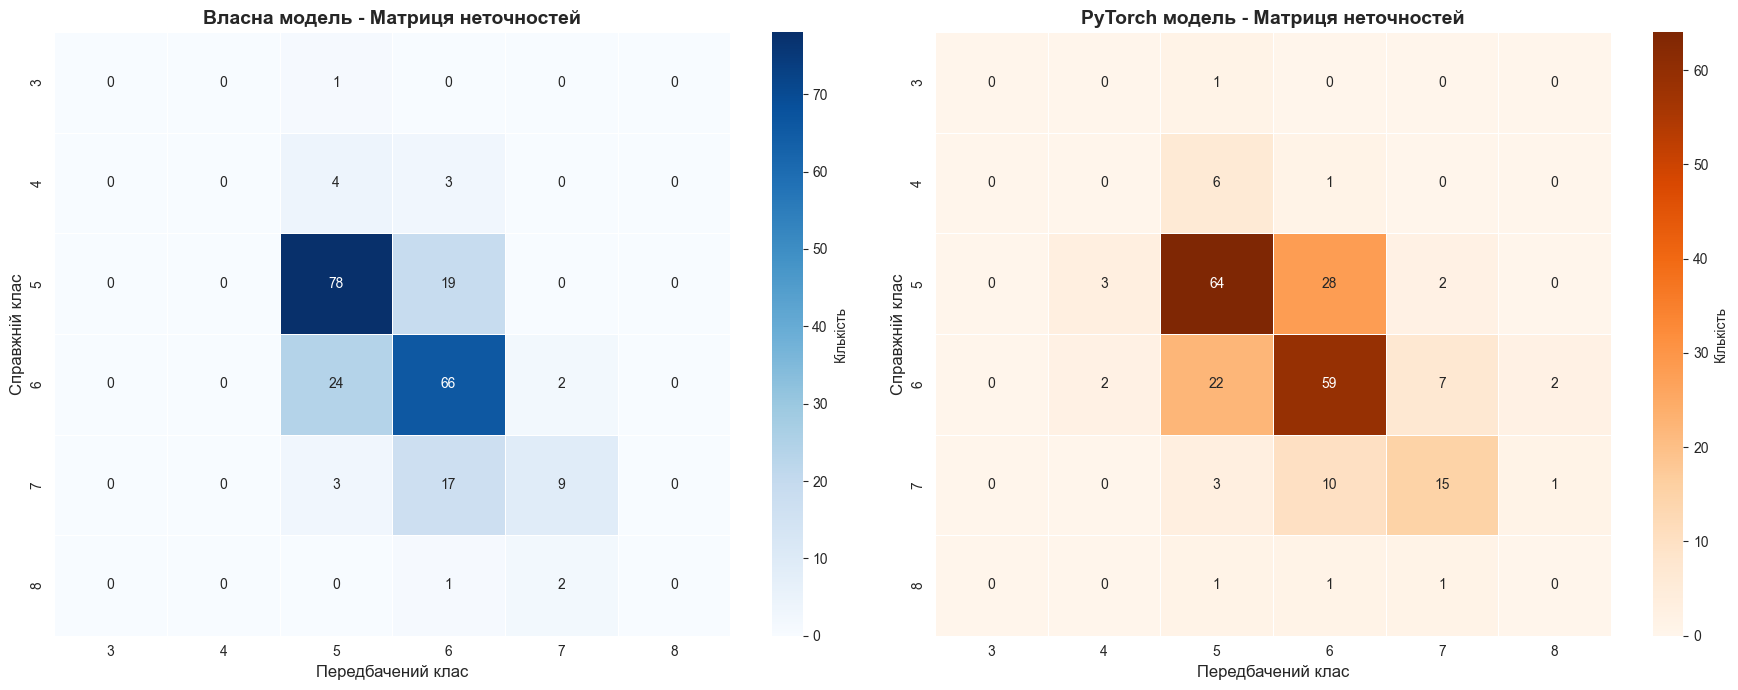


ЗВІТ КЛАСИФІКАЦІЇ - ВЛАСНА МОДЕЛЬ
              precision    recall  f1-score   support

      Клас 3       0.00      0.00      0.00         1
      Клас 4       0.00      0.00      0.00         7
      Клас 5       0.71      0.80      0.75        97
      Клас 6       0.62      0.72      0.67        92
      Клас 7       0.69      0.31      0.43        29
      Клас 8       0.00      0.00      0.00         3

    accuracy                           0.67       229
   macro avg       0.34      0.31      0.31       229
weighted avg       0.64      0.67      0.64       229


ЗВІТ КЛАСИФІКАЦІЇ - PYTORCH МОДЕЛЬ
              precision    recall  f1-score   support

      Клас 3       0.00      0.00      0.00         1
      Клас 4       0.00      0.00      0.00         7
      Клас 5       0.66      0.66      0.66        97
      Клас 6       0.60      0.64      0.62        92
      Клас 7       0.60      0.52      0.56        29
      Клас 8       0.00      0.00      0.00         3

    ac

In [35]:
# cell 17 - confusion matrices
visualize_confusion_matrices(y_test_numpy, custom_predictions, pytorch_predictions, class_labels)

# ВІДПОВІДІ НА ПИТАННЯ 
## Питання 1. Похідна комбінації Softmax + Cross-Entropy
**Завдання:** доведіть, що для комбінації Softmax активації та Cross-Entropy втрат, градієнт по відношенню до логітів вихідного шару обчислюється як:
∂L/∂z_i = y_pred_i - y_true_i


### Визначення функцій

Розглянемо вихідний шар нейронної мережі з логітами $z \in \mathbb{R}^K$. Функція softmax перетворює ці логіти в ймовірнісний розподіл:

$$y_i = \text{softmax}(z)_i = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

Функція втрат cross-entropy для one-hot вектора $y^{true}$ має вигляд:

$$L = -\sum_i y_i^{true} \log y_i$$

### Спрощення для класифікації

У випадку класифікації, коли правильний клас має індекс $k$, вектор $y^{true}$ містить одиницю лише на позиції $k$, а решта елементів дорівнюють нулю:

$$y_k^{true} = 1, \quad y_i^{true} = 0 \text{ для } i \neq k$$

Тому функція втрат спрощується до:

$$L = -\log y_k$$

### Обчислення похідної

Знаходимо градієнт функції втрат по логітам. Для цього використовуємо ланцюгове правило диференціювання:

$$\frac{\partial L}{\partial z_i} = \frac{\partial L}{\partial y_i} \cdot \frac{\partial y_i}{\partial z_i} + \sum_{j \neq i} \frac{\partial L}{\partial y_j} \cdot \frac{\partial y_j}{\partial z_i}$$

Розглянемо два випадки залежно від того, чи є $i$ правильним класом:

### Випадок 1: $i = k$ (правильний клас)

$$\frac{\partial L}{\partial z_k} = \frac{\partial (-\log y_k)}{\partial z_k} = -\frac{1}{y_k} \cdot \frac{\partial y_k}{\partial z_k}$$

Похідна softmax для діагонального елемента:

$$\frac{\partial y_k}{\partial z_k} = y_k(1 - y_k)$$

Підставляючи, отримуємо:

$$\frac{\partial L}{\partial z_k} = -\frac{1}{y_k} \cdot y_k(1 - y_k) = -(1 - y_k) = y_k - 1$$

### Випадок 2: $i \neq k$ (неправильний клас)

$$\frac{\partial L}{\partial z_i} = \frac{\partial (-\log y_k)}{\partial z_i} = -\frac{1}{y_k} \cdot \frac{\partial y_k}{\partial z_i}$$

Похідна softmax для недіагонального елемента:

$$\frac{\partial y_k}{\partial z_i} = -y_k y_i$$

Підставляючи, отримуємо:

$$\frac{\partial L}{\partial z_i} = -\frac{1}{y_k} \cdot (-y_k y_i) = y_i$$

### Загальна формула

Об'єднуючи обидва випадки в єдину векторну форму:

$$\boxed{\frac{\partial L}{\partial z_i} = y_i - y_i}$$

### Висновок

Градієнт функції втрат дорівнює **різниці між передбаченою ймовірністю та істинною міткою класу**. Ця елегантна форма є наслідком того, що похідна softmax і логарифм у cross-entropy алгебраїчно скорочуються.

Така властивість робить комбінацію softmax + cross-entropy дуже зручною для обчислень, оскільки градієнт обчислюється просто як різниця двох векторів без складних проміжних обчислень. Це забезпечує як **ефективність реалізації**, так і **чисельну стабільність** під час навчання нейронних мереж.



## Питання 2. Аналіз зміни градієнтів у глибоких мережах

### Похідна ReLU

$$\frac{d}{dx}\text{ReLU}(x) = \begin{cases} 
1, & x > 0 \\
0, & x \leq 0
\end{cases}$$

### Частина 1: Зміна градієнту після 100 ітерацій (60% мертвих нейронів)
#### Аналіз проблеми

У мережі з 5 шарами:
- 60% нейронів мертві (похідна = 0)
- 40% нейронів активні (похідна = 1)

#### Обчислення ймовірності проходження градієнту
Градієнт для першого шару обчислюється за ланцюговим правилом через усі шари. Ймовірність того, що конкретний нейрон отримає ненульовий градієнт:

$$P(\text{градієнт} \neq 0) = (0.4)^4 = 0.0256 = 2.56\%$$

(піднесено до степеня 4, бо градієнт проходить через 4 приховані шари)

### Наслідки
- Градієнт для першого шару буде в **~39 разів менший** (1/0.0256 ≈ 39), ніж для останнього шару
- **Dying ReLU problem**: нейрони з постійно від'ємними входами перестають навчатися
- Перший шар навчається **значно повільніше** або взагалі не навчається

### Частина 2: Максимальне значення градієнту для N шарів
Коли всі нейрони активні (похідна ReLU = 1), градієнт поширюється через добуток ваг:

$$\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial z_N} \prod_{i=2}^{N} W_i \cdot \frac{\partial z_1}{\partial W_1}$$

Якщо $||W_i|| \leq M$ для всіх шарів:

$$\boxed{\left|\left|\frac{\partial L}{\partial W_1}\right|\right|_{\max} \leq \left|\left|\frac{\partial L}{\partial z_N}\right|\right| \cdot M^{N-1} \cdot ||x||}$$

**Для 5 шарів:** градієнт $\propto M^4$

**Критичні випадки**
- $M > 1$ → вибухаючий градієнт
- $M < 1$ → зникаючий градієнт  
- $M \approx 1$ → стабільне навчання

**Висновок:** 
1. При 60% мертвих нейронів градієнт першого шару зменшується в ~39 разів
2. Максимальний градієнт залежить від добутку норм ваг: $\propto M^{N-1}$
3. ReLU у глибоких мережах потребує спеціальних технік: Batch Normalization, правильної ініціалізації, або skip connections.



## Питання 3. Умовність матричних операцій у backpropagation

### Постановка задачі
У backpropagation використовується:
$$dW = (1/m) \cdot dZ @ A_{prev}.T$$
Чому потрібне саме таке транспонування?

### Аналіз розмірностей

### Прямий прохід

$$Z = WX + b$$

Розмірності:
- $W$: $(n_{out}, n_{in})$ - ваги
- $X$: $(n_{in}, m)$ - вхідні дані ($m$ прикладів)
- $Z$: $(n_{out}, m)$ - вихід

### Зворотний прохід

Маємо:
- $dZ$: $(n_{out}, m)$ - градієнт по виходу

Потрібно знайти:
- $dW$: $(n_{out}, n_{in})$ - градієнт по вагам

### Виведення формули
За ланцюговим правилом, оскільки $Z = WX$:

$$\frac{\partial L}{\partial W} = \frac{\partial L}{\partial Z} \cdot \frac{\partial Z}{\partial W} = dZ \cdot X^T$$

З усередненням по batch:
$$\boxed{dW = \frac{1}{m} \cdot dZ @ X^T}$$

### Перевірка розмірностей

$$dW = \frac{1}{m} \cdot dZ @ A_{prev}^T$$

- $dZ$: $(n_{out}, m)$
- $A_{prev}^T$: $(m, n_{in})$
- Результат: $(n_{out}, m) \times (m, n_{in}) = (n_{out}, n_{in})$ ✓

**Збігається з розміром $W$!**

### Чому потрібне транспонування?
**Без транспонування:**
$$dZ @ A_{prev} = (n_{out}, m) \times (n_{in}, m)$$
❌ Неможливо помножити - внутрішні розмірності $(m \neq n_{in})$ не збігаються!

**З транспонуванням:**
$$dZ @ A_{prev}^T = (n_{out}, m) \times (m, n_{in})$$
✓ Можна помножити - внутрішні розмірності збігаються!

### Висновок

Транспонування $A_{prev}^T$ необхідне для:
1. Сумісності розмірностей матричного множення
2. Отримання правильної розмірності градієнта (як у $W$)
3. Математичної коректності відповідно до ланцюгового правила




## Питання 4. Аналіз власних значень Гессіана

### 1. Матриця Гессіана для двошарової мережі
Маємо просту мережу з двома шарами:

$$z_1 = W_1 x + b_1, \quad a_1 = \sigma(z_1)$$
$$z_2 = W_2 a_1 + b_2, \quad \hat{y} = \sigma(z_2)$$

Гессіан - це матриця других похідних функції втрат по параметрах:

$$H = \frac{\partial^2 L}{\partial W_1^2}$$

Якщо розписати через ланцюгове правило, отримаємо:

$$H \approx X^T \text{diag}(\sigma'(z_1)) W_2^T \text{diag}(\sigma'(z_2)) W_2 \text{diag}(\sigma'(z_1)) X$$

Тут бачимо, що Гессіан залежить від ваг другого шару $W_2$ та похідних функції активації.

### 2. Зв'язок власних значень зі швидкістю збіжності
Власні значення Гессіана показують, наскільки "крута" функція втрат у різних напрямках.

**Число обумовленості:**
$$\kappa = \frac{\lambda_{max}}{\lambda_{min}}$$

Чим більше це число, тим гірше:
- Якщо $\lambda_{min}$ маленьке - в деяких напрямках градієнт дуже маленький, навчання повільне
- Якщо $\lambda_{max}$ велике - в інших напрямках градієнт дуже великий, можуть бути стрибки

Кількість ітерацій для збіжності приблизно пропорційна $\kappa$. Тобто при $\kappa = 1000$ навчання буде в 1000 разів повільніше, ніж при $\kappa = 1$.

### 3. Зникаючі градієнти через призму власних значень
У глибокій мережі з $L$ шарами власні значення Гессіана виглядають приблизно так:

$$\lambda_H \sim \prod_{i=1}^{L} \lambda_{W_i}^2 \cdot (\sigma'(z_i))^2$$

Це добуток власних значень ваг та квадратів похідних активацій.

**Проблема виникає, коли:**
- Ваги мають малі власні значення ($\lambda_W < 1$)
- Похідна активації мала ($\sigma' < 1$)

Наприклад, для сигмоїди $\sigma' \leq 0.25$:

$$\lambda_H \sim (0.25)^{2L}$$

При $L = 5$ отримуємо $(0.0625)^5 \approx 0.000001$ - практично нуль!

**Що це означає:**
Власні значення експоненційно зменшуються з кількістю шарів. Коли власні значення дуже малі:
- Градієнти стають занадто малими для ефективного навчання
- Перші шари взагалі перестають навчатися
- Число обумовленості стає величезним ($\kappa \gg 1$)

**Чому саме зникають:**
Кожен новий шар множить власні значення на множник $< 1$. Після багатьох шарів отримуємо експоненційний спад. Це як помножити 0.5 саму на себе 10 разів - отримаємо дуже маленьке число.

**Рішення:**
- **Правильна ініціалізація** (Xavier/He) - робить $\lambda_W \approx 1$
- **Batch Normalization** - не дає активаціям насичуватися, підтримує $\sigma' \approx 1$
- **Skip connections** (ResNet) - градієнт може "обійти" шари напряму
- **ReLU** замість сигмоїди - похідна = 1 для додатних значень

### Висновок
Власні значення Гессіана показують, наскільки добре навчається мережа. У глибоких мережах вони експоненційно зменшуються через добуток багатьох множників $< 1$, що призводить до зникаючих градієнтів. Це можна виправити спеціальними методами.

## Висновки до лабораторної роботи
У цій лабораторній роботі було реалізовано багатошаровий перцептрон з нуля на PyTorch та досліджено його роботу на датасеті класифікації якості вина (WineQT).

**Основні результати:**
**1. Реалізація з нуля:** створено повноцінну нейронну мережу, включаючи функції активації (ReLU, Sigmoid, Tanh та інші), forward propagation, backpropagation та градієнтний спуск.

**2. Робота з даними:** датасет WineQT було підготовлено з розбиттям на тренувальну, валідаційну та тестову вибірки.

**3. Теоретичний аналіз:** детально розглянуто важливі питання (похідну Softmax + Cross-Entropy, проблему зникаючих градієнтів, необхідність транспортування матриць у backpropagation, звʼязок власних значент Гессіана з швидкістю збіжності).

Робота показала, що розуміння математичних основ backpropagation є критично важливим для ефективного налаштування та діагностики проблем у складних архітектурах, навіть при використанні готових фреймворків.